In [25]:
from warnings import filterwarnings
filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import sklearn
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
os.chdir("/home/lyonsja/Python/Data")

In [3]:
cancer=pd.read_csv('breast_cancer.csv')
cancer.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [4]:
round(cancer.diagnosis.value_counts()/len(cancer)*100, 1)

diagnosis
B    62.7
M    37.3
Name: count, dtype: float64

In [5]:
features=cancer.columns
features=list(features.drop('diagnosis'))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(cancer[features], cancer.diagnosis, 
                                                    stratify=cancer.diagnosis)

In [26]:
ss = StandardScaler().fit(X_train)
X_train_scaled = ss.transform(X_train)
X_test_scaled = ss.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
from sklearn.model_selection import GridSearchCV

In [29]:
pg = {'fit_intercept':[True,False], 'penalty':['l2','none']}

In [30]:
logreg_grid_search = GridSearchCV(LogisticRegression(), param_grid=pg, cv=5)

In [31]:
logreg_grid_search.fit(X_train_scaled, y_train)
print('Best parameters: {}'.format(logreg_grid_search.best_params_))
print('Five-fold cross-validation score: {:.3f}'.format(logreg_grid_search.best_score_))
print('Test score: {:.3f}'.format(logreg_grid_search.score(X_test_scaled, y_test)))

Best parameters: {'fit_intercept': True, 'penalty': 'l2'}
Five-fold cross-validation score: 0.979
Test score: 0.979


In [16]:
svm = SVC()
svm.fit(X_train_scaled, y_train)

SVC()

In [22]:
print("Support Vector Machine")
print("=========================================")
print("Training score: {:.2f}".format(svm.score(X_train_scaled, y_train)))
print("Test score: {:.2f}".format(svm.score(X_test_scaled, y_test)))
print("=========================================")

Support Vector Machine
Training score: 0.98
Test score: 0.97


In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
param_grid = {'max_depth':[3,4,5], 'min_samples_leaf':[1,2,5], 'criterion':['entropy']}
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

In designing a classification decision tree one wants to split the data along features which will maximize the impurity of the split. If $p_1$ is the probability of class 1 and $p_0=1-p_1$ is the probability of class 0 then the entropy is
$$
H(p_1) = -p_1 \text{log}_2(p_1) - p_0 \text{log}_2(p_0).
$$
The optimal split of a decision tree will minimize entropy. The *information gain* is the difference between the entropy of the root and the weighted average entropy of the split. For example, let's say at some root that 5 out of 10 things are class 1 and there is a split to two nodes. On the left node is 4 of the class 1 and the remaining 1 goes to the right node.
$$
\text{Information Gain}=H(0.5) - \left[\frac{5}{10}H(0.8) + \frac{5}{10}H(0.2)\right].
$$
In general, if the proportion of class 1 on the left and right nodes are $w_1^{left}$ and $w_1^{right}$ respectively then
$$
\text{Information Gain}=H(p_1^{root}) - \left[w_1^{left}H(p_1^{left}) + w_1^{right}H(p_1^{right})\right].
$$

In [35]:
grid_search.fit(X_train_scaled, y_train)
print('Best parameters: {}'.format(grid_search.best_params_))
print('Five-fold cross-validation score: {:.3f}'.format(grid_search.best_score_))
print('Test score: {:.3f}'.format(grid_search.score(X_test_scaled, y_test)))

Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}
Five-fold cross-validation score: 0.944
Test score: 0.930


In [36]:
from sklearn import tree

In [37]:
import matplotlib.pyplot as plt

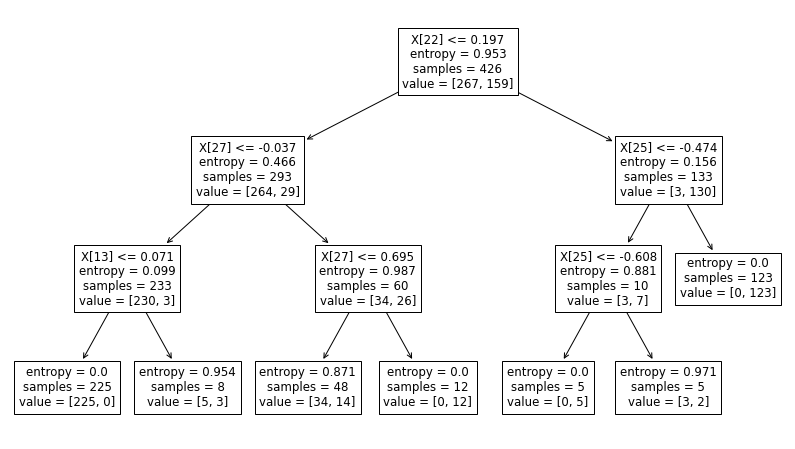

In [38]:
bestTree=grid_search.best_estimator_
fig, ax = plt.subplots(figsize=(14,8))
tree.plot_tree(bestTree)
plt.show()